In [22]:
from statistic import calcular_medidas_descritivas, calcular_outliers
from distribuicao import analisar_assimetria_curtose
from graficos import gerar_histograma, gerar_painel_boxplot
import pandas as pd
import mysql.connector

In [23]:
# FUNÇÃO DE CONEXÃO COM O MYSQL

def obter_dados_do_banco(query):
    try:
        conexao = mysql.connector.connect(
            host="localhost",
            user="root",
            password="123456",
            database="projeto_vacinas"
        )

        cursor = conexao.cursor()
        cursor.execute(query)

        resultados = cursor.fetchall()

        return resultados

    except mysql.connector.Error as erro:
        print(f"Erro ao conectar ao MySQL: {erro}")
        return None

    finally:
        if 'conexao' in locals() and conexao.is_connected():
            cursor.close()
            conexao.close()

In [38]:
# CONSULTA DOS DADOS

query_idades = """
SELECT 
    'AC' AS estado,
    paciente_idade
FROM vacinacao_ac
WHERE paciente_idade IS NOT NULL

UNION ALL

SELECT 
    'AP' AS estado,
    paciente_idade
FROM vacinacao_ap
WHERE paciente_idade IS NOT NULL
"""

dados = obter_dados_do_banco(query_idades)

df = pd.DataFrame(
    dados,
    columns=['estado', 'paciente_idade']
)

# Convertendo para float
df['paciente_idade'] = df['paciente_idade'].astype(float)

print("---- ACRE ----")
print(
    df[df['estado'] == 'AC']
    .head()
    .reset_index(drop=True)
)

print("\n----- AMAPÁ -----")
print(
    df[df['estado'] == 'AP']
    .head()
    .reset_index(drop=True)
)

---- ACRE ----
  estado  paciente_idade
0     AC            30.0
1     AC            45.0
2     AC            14.0
3     AC            71.0
4     AC            32.0

----- AMAPÁ -----
  estado  paciente_idade
0     AP             1.0
1     AP            40.0
2     AP             1.0
3     AP            41.0
4     AP            25.0


In [25]:
# PREPARAÇÃO DOS DADOS

idades_ac = df[df['estado'] == 'AC']['paciente_idade'].values

idades_ap = df[df['estado'] == 'AP']['paciente_idade'].values

print("Idades Acre:")
print(idades_ac)

print("\nIdades Amapá:")
print(idades_ap)

Idades Acre:
[30. 45. 14. ... 53. 17. 37.]

Idades Amapá:
[ 1. 40.  1. ... 55.  8. 54.]


In [39]:
# MEDIDAS DESCRITIVAS

print("----- ACRE -----")

medidas_ac = calcular_medidas_descritivas(idades_ac)

print("\n----- AMAPÁ -----")

medidas_ap = calcular_medidas_descritivas(idades_ap)

----- ACRE -----

===== MEDIDAS DESCRITIVAS =====
Média: 35.73
Mediana: 34.00
Moda: 18.00
Desvio Padrão: 19.74
Q1: 20.00
Q2 (Mediana): 34.00
Q3: 49.00
IQR: 29.00
Distância entre Média e Mediana: 5.07%
A média tende a ser uma medida confiável.

----- AMAPÁ -----

===== MEDIDAS DESCRITIVAS =====
Média: 34.28
Mediana: 32.00
Moda: 12.00
Desvio Padrão: 20.41
Q1: 18.00
Q2 (Mediana): 32.00
Q3: 49.00
IQR: 31.00
Distância entre Média e Mediana: 7.12%
A média tende a ser uma medida confiável.


In [41]:
# OUTLIERS

print("----- OUTLIERS ACRE -----")

outliers_ac = calcular_outliers(idades_ac)

print("\n----- OUTLIERS AMAPÁ -----")

outliers_ap = calcular_outliers(idades_ap)

----- OUTLIERS ACRE -----

===== OUTLIERS =====
Q1: 20.00
Q3: 49.00
IQR: 29.00
Limite Inferior: -23.50
Limite Superior: 92.50

Quantidade de outliers inferiores: 0
Quantidade de outliers superiores: 592

----- OUTLIERS AMAPÁ -----

===== OUTLIERS =====
Q1: 18.00
Q3: 49.00
IQR: 31.00
Limite Inferior: -28.50
Limite Superior: 95.50

Quantidade de outliers inferiores: 0
Quantidade de outliers superiores: 271


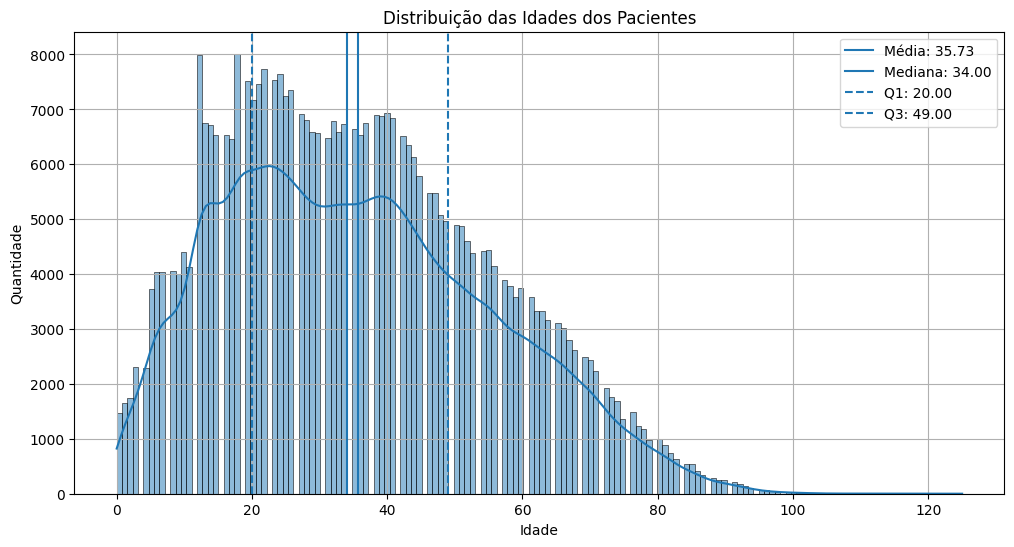

In [28]:
# HISTOGRAMA - ACRE

gerar_histograma(idades_ac)

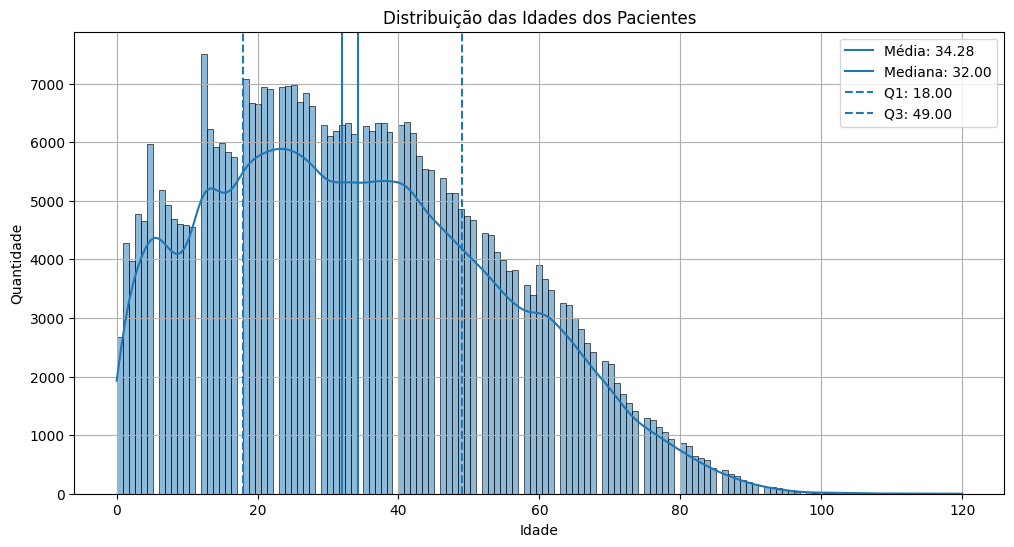

In [29]:
# HISTOGRAMA - AMAPÁ

gerar_histograma(idades_ap)

Painel salvo em: Relatorio_Idades_AC.png


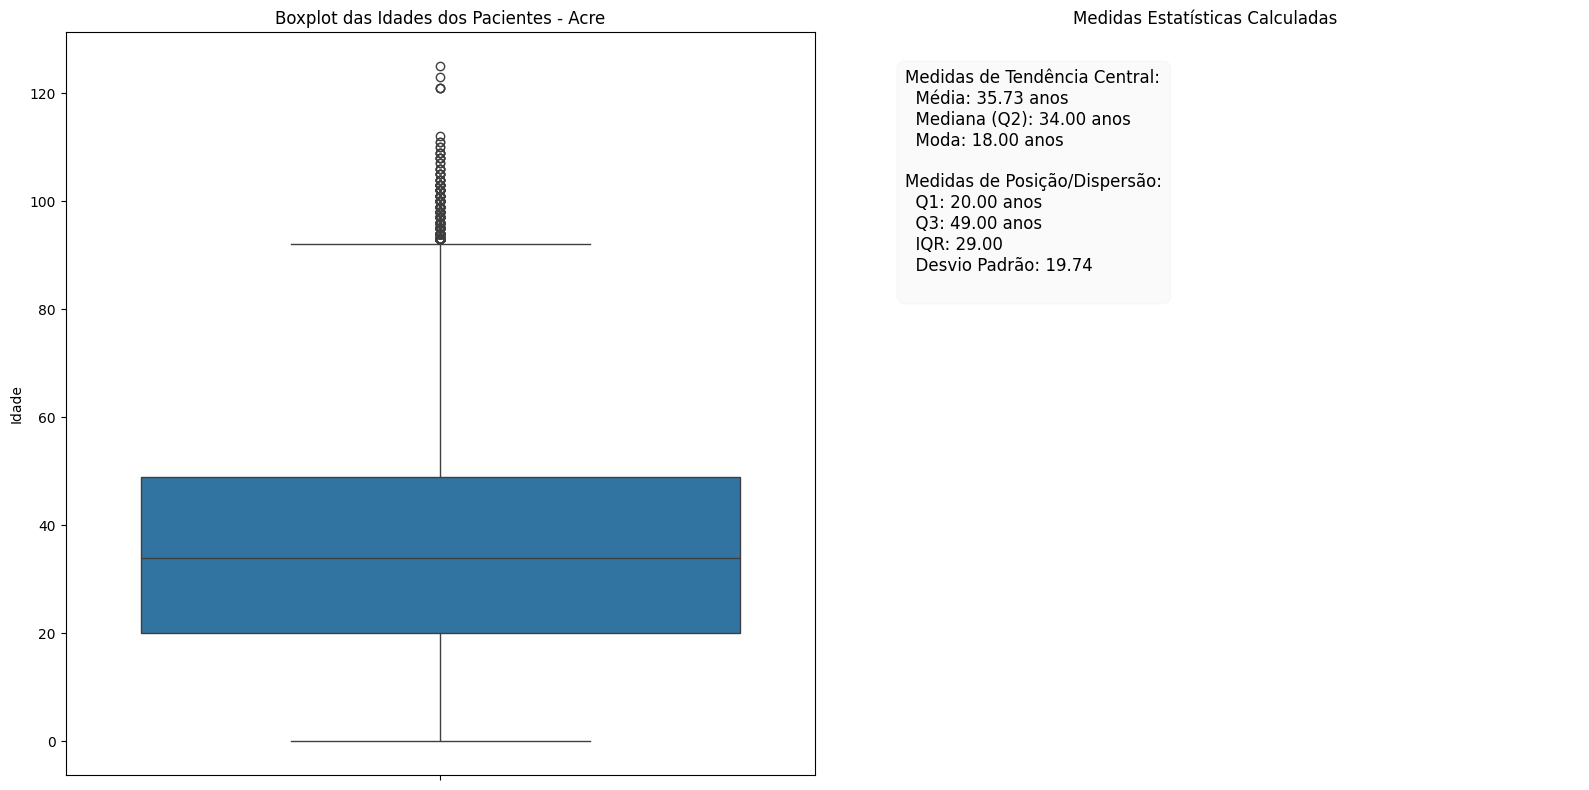

In [30]:
# BOXPLOT - ACRE

gerar_painel_boxplot(
    idades_ac,
    medidas_ac,
    titulo_boxplot='Boxplot das Idades dos Pacientes - Acre',
    caminho_salvar='Relatorio_Idades_AC.png'
)

Painel salvo em: Relatorio_Idades_AP.png


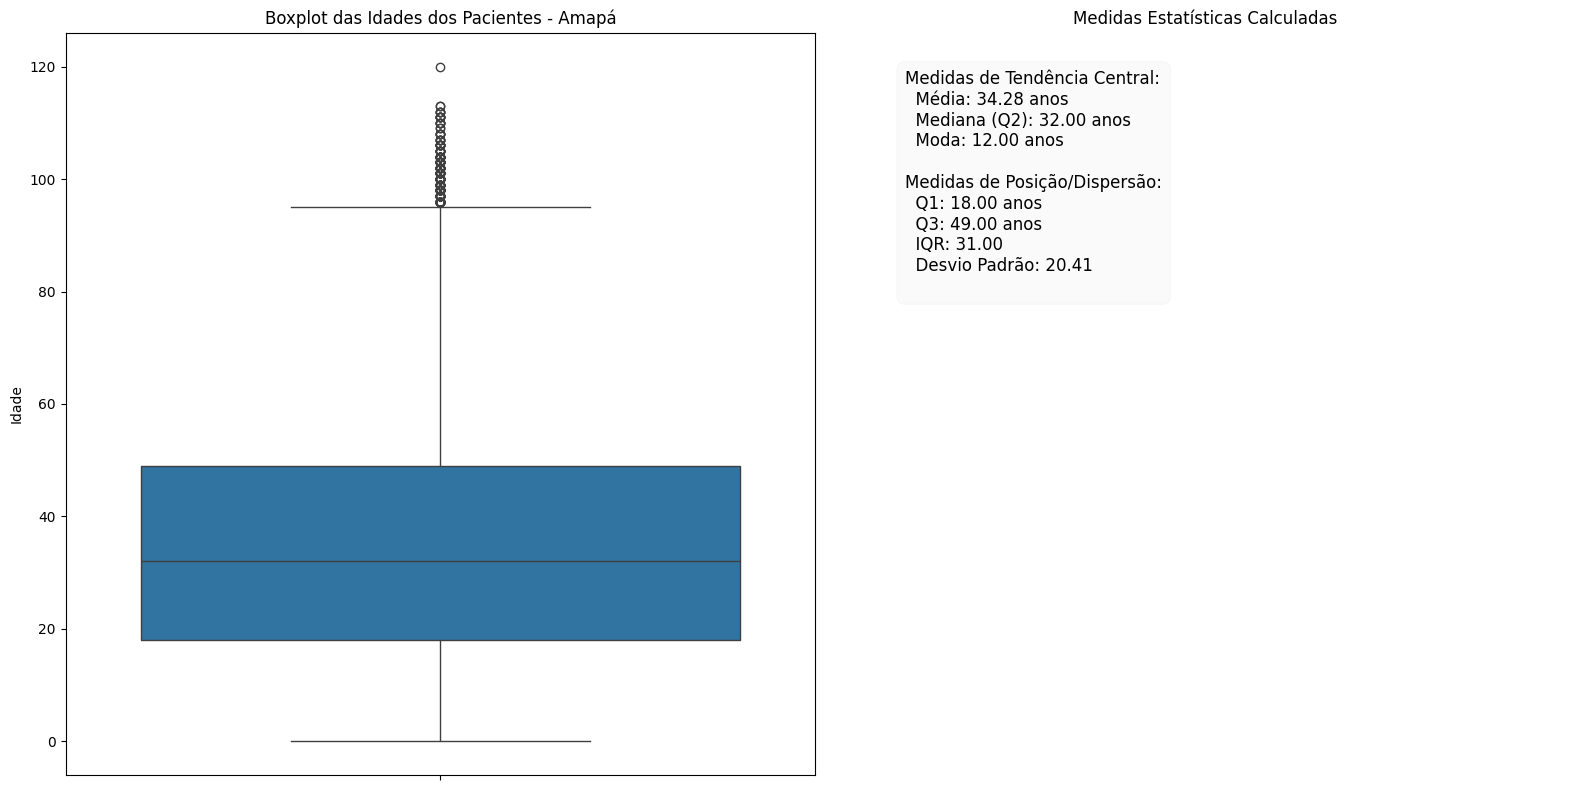

In [31]:
# BOXPLOT - AMAPÁ

gerar_painel_boxplot(
    idades_ap,
    medidas_ap,
    titulo_boxplot='Boxplot das Idades dos Pacientes - Amapá',
    caminho_salvar='Relatorio_Idades_AP.png'
)

In [43]:
# ASSIMETRIA E CURTOSE - ACRE

print("----- ACRE -----")

analise_ac = analisar_assimetria_curtose(idades_ac)

----- ACRE -----

===== ASSIMETRIA =====
Assimetria das Idades: 0.4201
Média: 35.73
Mediana: 34.00

Conclusão da Assimetria: Simétrica ou quase simétrica. Média e mediana são próximas.

===== CURTOSE =====
Curtose em Excesso (Pandas): -0.5098
Curtose Real (Referência 3.0): 2.4902

Conclusão da Curtose: Platicúrtica. Dados mais dispersos em relação à média, com curva mais achatada.


In [42]:
# ASSIMETRIA E CURTOSE - AMAPÁ

print("\n----- AMAPÁ ----")

analise_ap = analisar_assimetria_curtose(idades_ap)


----- AMAPÁ ----

===== ASSIMETRIA =====
Assimetria das Idades: 0.3788
Média: 34.28
Mediana: 32.00

Conclusão da Assimetria: Simétrica ou quase simétrica. Média e mediana são próximas.

===== CURTOSE =====
Curtose em Excesso (Pandas): -0.5762
Curtose Real (Referência 3.0): 2.4238

Conclusão da Curtose: Platicúrtica. Dados mais dispersos em relação à média, com curva mais achatada.
